This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - always picking 5 tasks. 

In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct


In [2]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')

# start with some U_true, in this simulation its 5 tasks x 5 parcels

In [3]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [4]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [5]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

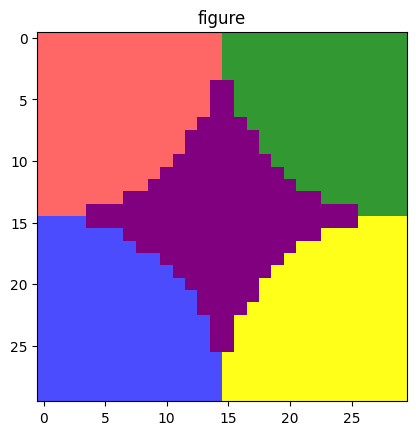

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

# Make a random task battery with 30 task and plot second moment matrix

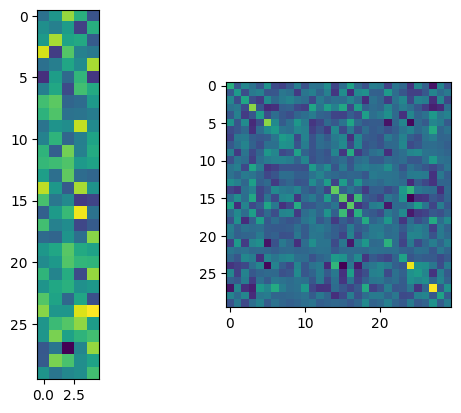

In [7]:
num_task_lib = 30
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

# prep inputs

In [8]:
Y_true = V_lib @ np.array(U_true_5)
Y_true = Y_true.reshape(1,Y_true.shape[0],Y_true.shape[1])
U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])


In [9]:
Y_true = pt.tensor(Y_true, dtype=pt.float32, device=device)
V_lib = pt.tensor(V_lib, dtype=pt.float32, device=device)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32,device=device)

C:\Users\barafat\AppData\Local\Temp\ipykernel_14000\504040485.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_true_5 = pt.tensor(U_true_5, dtype=pt.float32,device=device)


# Run

In [10]:
# 2 to 24 steps of 2
battery_sizes = [3,4,6,8,10,14,18,24]
max_battery_size = max(battery_sizes)
noise = 5
metrics = ['variance','log_det_mc','inverse_trace_mc']

In [11]:
results_df = []
for n_task in battery_sizes:
    print(f"Processing battery size: {n_task}")
    # Generate possible battery combinations for current battery size and calculate eigenmetrics
    D = ct.build_combinations(G_lib=G_lib, strategy='random',n_batteries=500000,n_tasks=n_task,seed=3,replacement=False,rest_idx=None)
    
    for metric in metrics:
        top_5 = D.nlargest(5, metric)
        top_5 = top_5.reset_index(drop=True)
        D_ev = sim.evluate_dataframe_simulation(D = top_5, YLib= Y_true,VLib=V_lib,n_iter=1,noise=noise, U_true=U_true_5,method ='correlation', noise_method = 'weighted',max_n_task=max_battery_size)
        average_cos_mean = D_ev['percent_correct'].mean().item()
        # append all information to the results dataframe as a dictionary
        results_df.append({'n_task':n_task,'metric':metric,'percent_correct':average_cos_mean})

results_df = pd.DataFrame(results_df)
    

Processing battery size: 3
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 10
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 14
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 18
Processing combination: 0
Processing combination: 0
Processing combination: 0
Processing battery size: 24
Processing combination: 0
Processing combination: 0
Processing combination: 0


<Axes: xlabel='n_task', ylabel='percent_correct'>

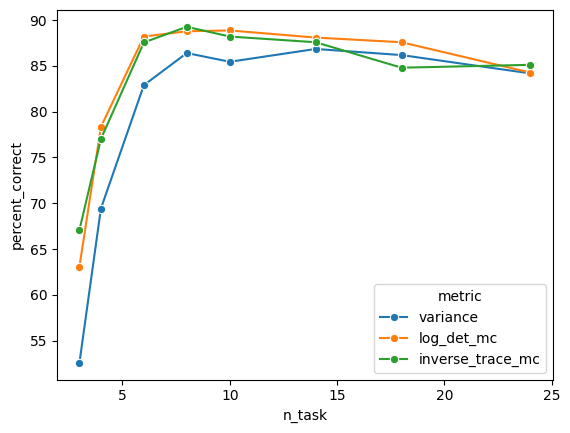

In [12]:
sns.lineplot(data=results_df, x="n_task", y="percent_correct", hue="metric", marker="o")